In [6]:
# Cell 1 — Imports and utility functions
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import util, metrics  # skimage used for PSNR/MSE (optional)
import os

# Display settings for matplotlib
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['image.interpolation'] = 'nearest'

def read_image_rgb(path):
    img_bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if img_bgr is None:
        print(f"[ERROR] File not found: {path}")
        return None
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_rgb

def show_images(images, titles=None, cmap=None):
    n = len(images)
    plt.figure(figsize=(5*n,5))
    for i, img in enumerate(images):
        plt.subplot(1,n,i+1)
        if titles: plt.title(titles[i])
        if img.ndim == 2:
            plt.imshow(img, cmap=cmap if cmap else 'gray')
        else:
            plt.imshow(img)
        plt.axis('off')
    plt.show()

def plot_rgb_histograms(rgb_img, bins=256, title_prefix=""):
    if rgb_img is None: 
        print("No image provided.")
        return
    r = rgb_img[:,:,0].ravel()
    g = rgb_img[:,:,1].ravel()
    b = rgb_img[:,:,2].ravel()
    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    plt.hist(r, bins=bins, alpha=0.6, label='R', density=False)
    plt.hist(g, bins=bins, alpha=0.6, label='G', density=False)
    plt.hist(b, bins=bins, alpha=0.6, label='B', density=False)
    plt.legend()
    plt.title(f"{title_prefix} RGB channel histograms")
    plt.xlabel('Intensity (0-255)')
    plt.ylabel('Count')

    # Luminance (Rec. 709 / perceptual weights) or use cv2.cvtColor to grayscale
    lum = (0.2126*r + 0.7152*g + 0.0722*b)
    plt.subplot(1,2,2)
    plt.hist(lum, bins=bins, alpha=0.9)
    plt.title(f"{title_prefix} Luminance histogram")
    plt.xlabel('Luminance (approx)')
    plt.ylabel('Count')
    plt.show()

def save_image_rgb(path, img_rgb):
    
    if img_rgb is None: 
        print(f"Not saving {path}: image is None")
        return
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    cv2.imwrite(path, img_bgr)
    print(f"Saved: {path}")



FirstI shape: (243, 322, 3) dtype: uint8


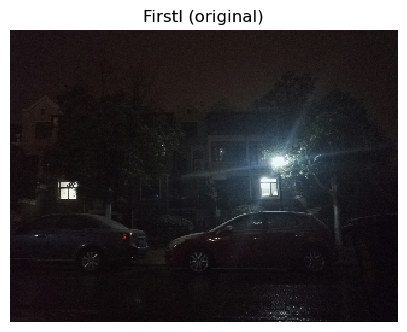

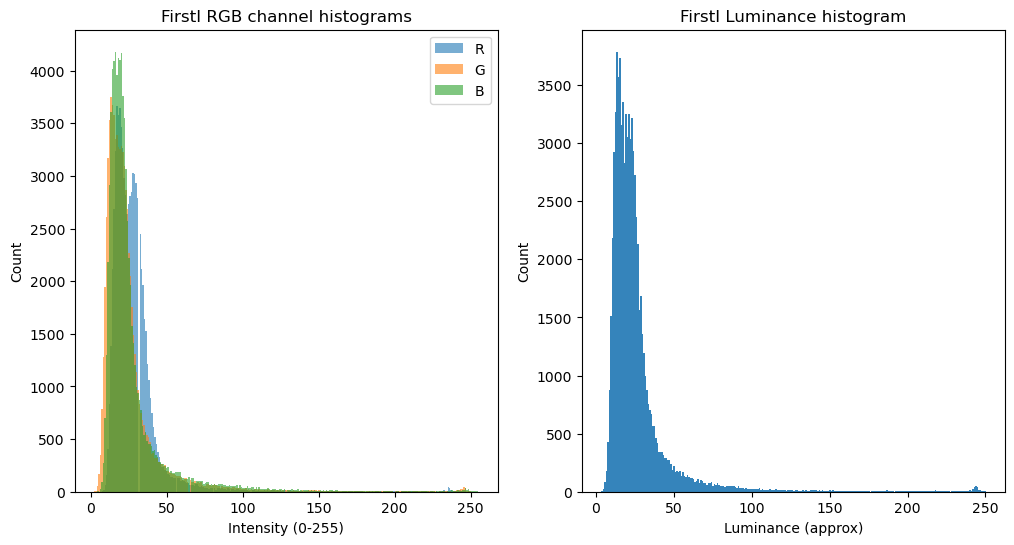

In [17]:
# Cell 2 — Load FirstI = night.png and show basic info + original histograms
first_path = "night.png"
FirstI = read_image_rgb(first_path)
if FirstI is None:
    # If file missing create a small placeholder so later code doesn't crash (only for demonstration)
    FirstI = np.zeros((200,300,3), dtype=np.uint8)
    FirstI[:] = (20,20,30)  # dark placeholder
    print("Using placeholder FirstI (night.png missing).")

print("FirstI shape:", FirstI.shape, "dtype:", FirstI.dtype)
show_images([FirstI], ["FirstI (original)"])
plot_rgb_histograms(FirstI, title_prefix="FirstI")


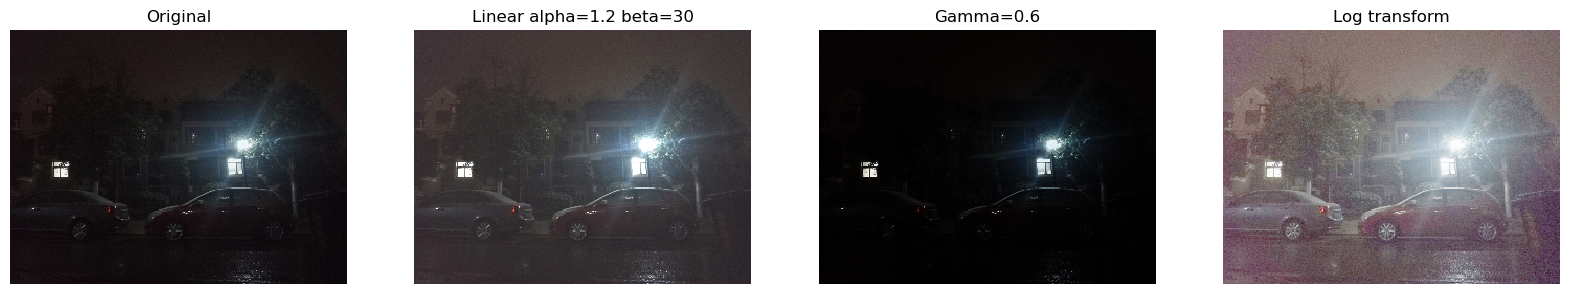

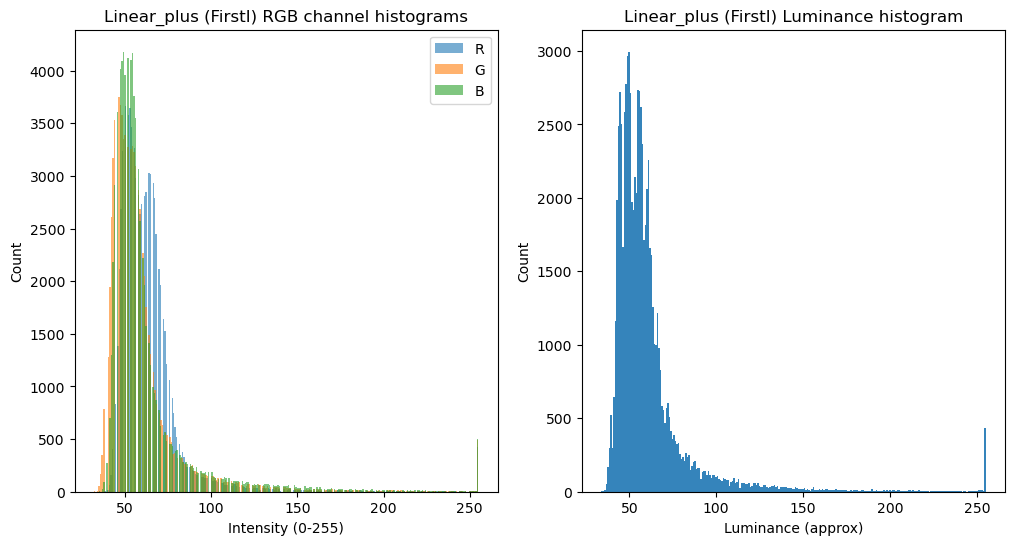

In [8]:
# Cell 3 — 2. Linear transformations (brightness/contrast) and nonlinear (gamma/log)
# Linear: new = alpha * img + beta  (alpha: contrast, beta: brightness)
def linear_transform(img, alpha=1.0, beta=0):
    # img expected in uint8 RGB
    res = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
    return res

# Nonlinear: Gamma correction and Log transform
def gamma_correction(img, gamma=1.0):
    invGamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** invGamma) * 255
                      for i in np.arange(256)]).astype("uint8")
    return cv2.LUT(img, table)

def log_transform(img):
    # Convert to float, apply log(1+I), normalize back to 0-255
    img_float = img.astype(np.float32)
    log_img = np.log1p(img_float)
    # normalize to 0-255
    log_img = 255 * (log_img - log_img.min()) / (log_img.max() - log_img.min() + 1e-8)
    return log_img.astype(np.uint8)

# Apply several variants
linear_plus = linear_transform(FirstI, alpha=1.2, beta=30)  # brighten + slight contrast
linear_strong = linear_transform(FirstI, alpha=1.5, beta=40)  # stronger
gamma_low = gamma_correction(FirstI, gamma=0.6)   # gamma <1 brightens shadows
gamma_high = gamma_correction(FirstI, gamma=1.6)  # gamma >1 darkens
log_img = log_transform(FirstI)

# Show
show_images([FirstI, linear_plus, gamma_low, log_img],
            ["Original", "Linear alpha=1.2 beta=30", "Gamma=0.6", "Log transform"])
# Show histograms for one enhanced result
plot_rgb_histograms(linear_plus, title_prefix="Linear_plus (FirstI)")


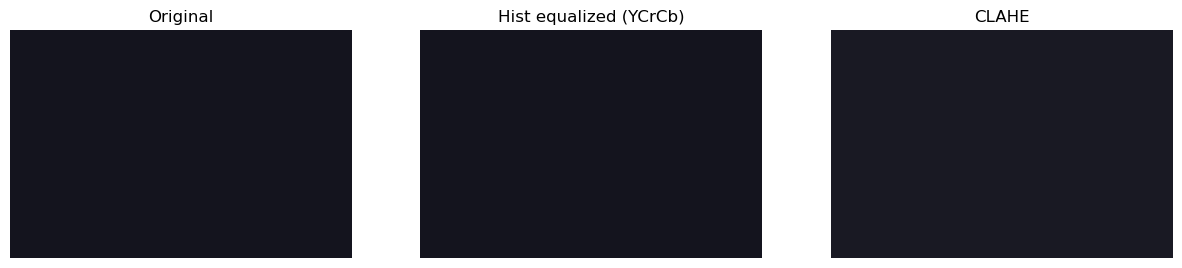

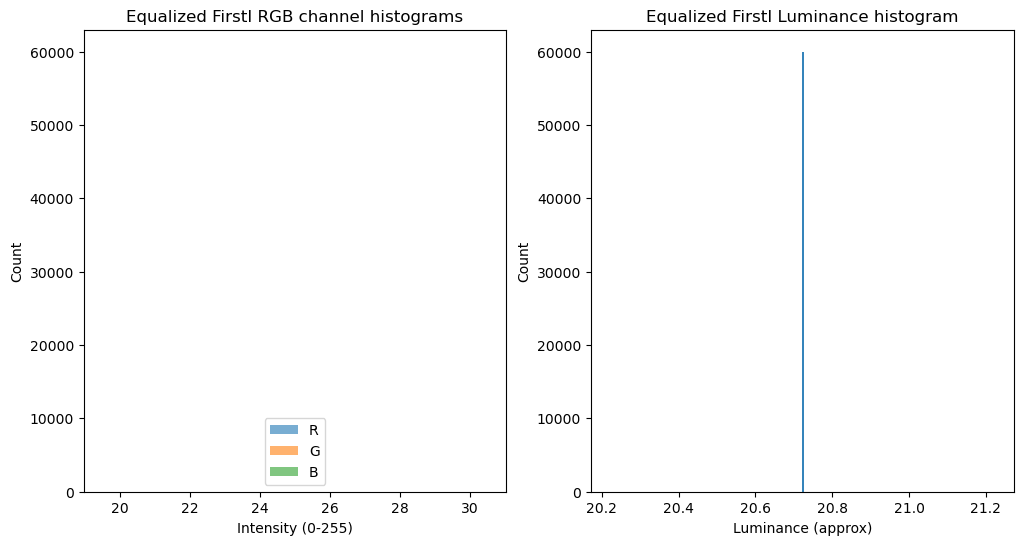

In [4]:
# Cell 4 — 3. Histogram equalization for FirstI
# For color images, do equalization on luminance channel (Y in YCrCb) to avoid color shifts.

def hist_eq_color(img_rgb):
    img_ycrcb = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YCrCb)
    y, cr, cb = cv2.split(img_ycrcb)
    y_eq = cv2.equalizeHist(y)
    ycrcb_eq = cv2.merge((y_eq, cr, cb))
    rgb_eq = cv2.cvtColor(ycrcb_eq, cv2.COLOR_YCrCb2RGB)
    return rgb_eq

def clahe_color(img_rgb, clipLimit=2.0, tileGridSize=(8,8)):
    img_ycrcb = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YCrCb)
    y, cr, cb = cv2.split(img_ycrcb)
    clahe = cv2.createCLAHE(clipLimit=clipLimit, tileGridSize=tileGridSize)
    y_clahe = clahe.apply(y)
    merged = cv2.merge((y_clahe, cr, cb))
    rgb_clahe = cv2.cvtColor(merged, cv2.COLOR_YCrCb2RGB)
    return rgb_clahe

eq_img = hist_eq_color(FirstI)
clahe_img = clahe_color(FirstI, clipLimit=3.0, tileGridSize=(8,8))

show_images([FirstI, eq_img, clahe_img], ["Original", "Hist equalized (YCrCb)", "CLAHE"])
plot_rgb_histograms(eq_img, title_prefix="Equalized FirstI")


In [9]:
# Cell 5 — Extra: Save results and print a checklist (completing "experiment requirements")
out_dir = "results"
os.makedirs(out_dir, exist_ok=True)
save_image_rgb(os.path.join(out_dir, "FirstI_linear_plus.png"), linear_plus)
save_image_rgb(os.path.join(out_dir, "FirstI_gamma_low.png"), gamma_low)
save_image_rgb(os.path.join(out_dir, "FirstI_log.png"), log_img)
save_image_rgb(os.path.join(out_dir, "FirstI_equalized.png"), eq_img)
save_image_rgb(os.path.join(out_dir, "FirstI_clahe.png"), clahe_img)

print("Checklist for FirstI processed:")
print("- Computed and displayed R,G,B and luminance histograms ✔")
print("- Performed linear enhancements (alpha/beta) and showed result ✔")
print("- Performed nonlinear enhancements (gamma, log) and showed result ✔")
print("- Performed histogram equalization and CLAHE and showed results ✔")
print("- Saved enhanced images to results/ ✔")


Saved: results/FirstI_linear_plus.png
Saved: results/FirstI_gamma_low.png
Saved: results/FirstI_log.png
Saved: results/FirstI_equalized.png
Saved: results/FirstI_clahe.png
Checklist for FirstI processed:
- Computed and displayed R,G,B and luminance histograms ✔
- Performed linear enhancements (alpha/beta) and showed result ✔
- Performed nonlinear enhancements (gamma, log) and showed result ✔
- Performed histogram equalization and CLAHE and showed results ✔
- Saved enhanced images to results/ ✔


SecI shape: (256, 256, 3)


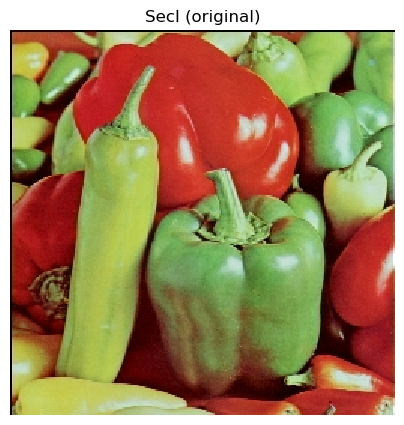

In [10]:
# Cell 6 — Load SecI = peppers.jpg
sec_path = "peppers.jpg"
SecI = read_image_rgb(sec_path)
if SecI is None:
    SecI = cv2.imread(cv2.samples.findFile("img001.jpg"), cv2.IMREAD_COLOR)
    if SecI is not None:
        SecI = cv2.cvtColor(SecI, cv2.COLOR_BGR2RGB)
        print("Loaded sample fallback image for SecI.")
    else:
        # placeholder
        SecI = np.full((300,400,3), 128, dtype=np.uint8)
        print("Using placeholder SecI (peppers.jpg missing).")

print("SecI shape:", SecI.shape)
show_images([SecI], ["SecI (original)"])


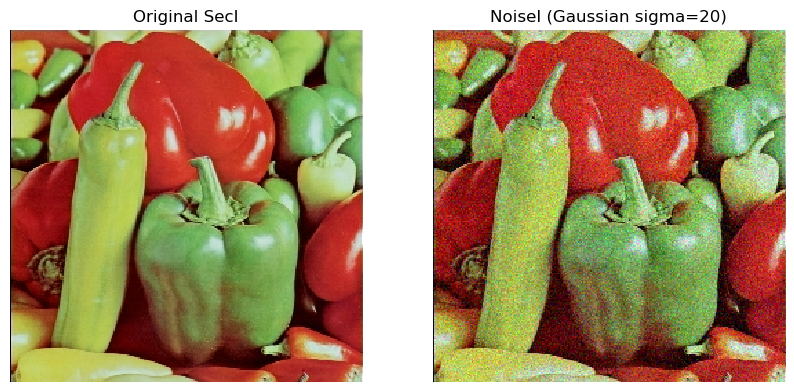

In [11]:
# Cell 7 — 1. Add Gaussian noise to SecI -> NoiseI
def add_gaussian_noise(img_rgb, mean=0.0, sigma=15.0):
    """Add Gaussian noise; img_rgb uint8 in [0,255]."""
    gauss = np.random.normal(mean, sigma, img_rgb.shape).astype(np.float32)
    noisy = img_rgb.astype(np.float32) + gauss
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)
    return noisy

NoiseI = add_gaussian_noise(SecI, mean=0.0, sigma=20.0)
show_images([SecI, NoiseI], ["Original SecI", "NoiseI (Gaussian sigma=20)"])


In [12]:
# PSNR and MSE
def compute_metrics(a, b):
    a_f = a.astype(np.float32)
    b_f = b.astype(np.float32)
    mse = np.mean((a_f - b_f)**2)
    if mse == 0:
        psnr = float('inf')
    else:
        PIXEL_MAX = 255.0
        psnr = 10 * np.log10((PIXEL_MAX**2) / mse)
    return mse, psnr

mse_n, psnr_n = compute_metrics(SecI, NoiseI)
print(f"NoiseI vs original — MSE: {mse_n:.2f}, PSNR: {psnr_n:.2f} dB")


NoiseI vs original — MSE: 377.72, PSNR: 22.36 dB


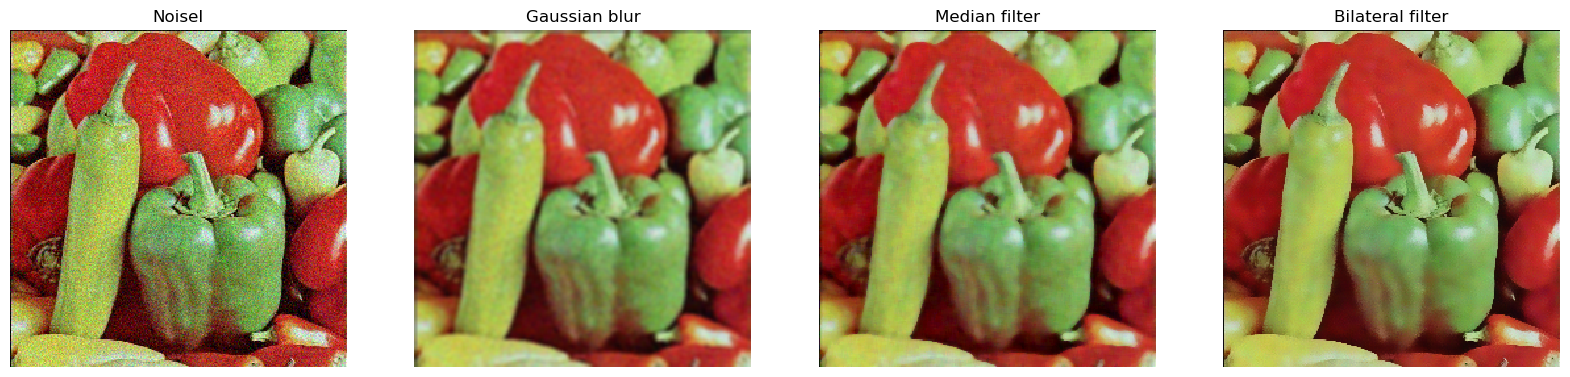

Gaussian smoothing — MSE: 210.25, PSNR: 24.90 dB
Median smoothing — MSE: 140.76, PSNR: 26.65 dB
Bilateral smoothing — MSE: 69.59, PSNR: 29.71 dB


In [13]:
# Cell 8 — 2. Smoothing filters for NoiseI -> SmoothI
# We'll design & try: (a) Gaussian blur, (b) Median filter, (c) Bilateral filter
def gaussian_smooth(img, ksize=5, sigma=1.0):
    return cv2.GaussianBlur(img, (ksize,ksize), sigma)

def median_smooth(img, ksize=5):
    # cv2.medianBlur expects single- or 3-channel uint8
    return cv2.medianBlur(img, ksize)

def bilateral_smooth(img, d=9, sigmaColor=75, sigmaSpace=75):
    return cv2.bilateralFilter(img, d, sigmaColor, sigmaSpace)

smooth_gauss = gaussian_smooth(NoiseI, ksize=5, sigma=1.5)
smooth_median = median_smooth(NoiseI, ksize=5)
smooth_bilateral = bilateral_smooth(NoiseI, d=9, sigmaColor=75, sigmaSpace=75)

show_images([NoiseI, smooth_gauss, smooth_median, smooth_bilateral],
            ["NoiseI", "Gaussian blur", "Median filter", "Bilateral filter"])

# Compute metrics
for name, sm in [("Gaussian", smooth_gauss), ("Median", smooth_median), ("Bilateral", smooth_bilateral)]:
    mse_s, psnr_s = compute_metrics(SecI, sm)
    print(f"{name} smoothing — MSE: {mse_s:.2f}, PSNR: {psnr_s:.2f} dB")


Saved: results/SecI_NoiseI.png
Saved: results/SecI_SmoothI.png


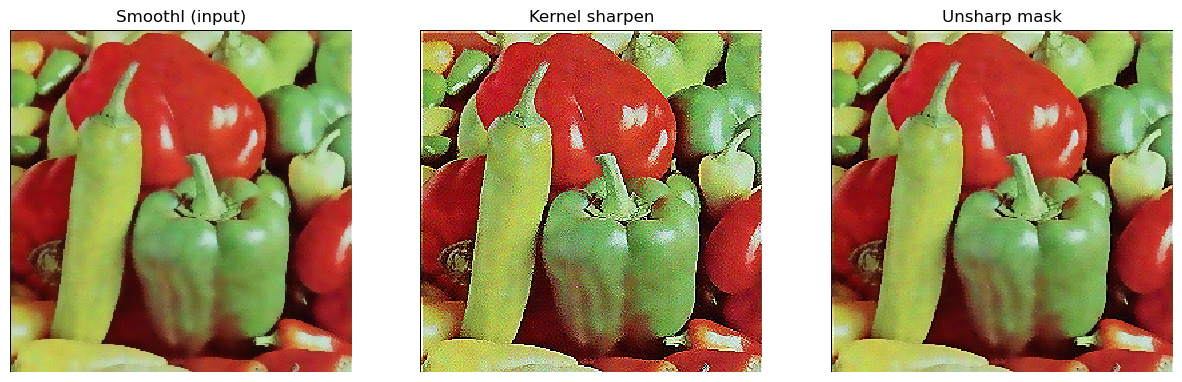

Kernel sharpen MSE: 876.66, PSNR: 18.70 dB
Unsharp mask MSE: 116.35, PSNR: 27.47 dB
Saved: results/SecI_SharpenI.png


In [15]:
# Cell 9 — 3. Design a sharpening filter for SmoothI -> SharpenI
# Two methods: (A) Kernel sharpening (unsharp mask via kernel), (B) Unsharp Masking (image - blurred)

SmoothI = smooth_bilateral.copy()
save_image_rgb(os.path.join(out_dir, "SecI_NoiseI.png"), NoiseI)
save_image_rgb(os.path.join(out_dir, "SecI_SmoothI.png"), SmoothI)

# A: simple kernel
kernel_sharp = np.array([[0, -1, 0],
                         [-1, 5, -1],
                         [0, -1, 0]], dtype=np.float32)

def kernel_sharpen(img, kernel=kernel_sharp):
    return cv2.filter2D(img, -1, kernel)

# B: unsharp mask
def unsharp_mask(img, sigma=1.0, strength=1.5):
    blurred = cv2.GaussianBlur(img, (0,0), sigma)
    sharpened = cv2.addWeighted(img, 1.0 + strength, blurred, -strength, 0)
    # clip
    return np.clip(sharpened, 0, 255).astype(np.uint8)

sharpen_kernel = kernel_sharpen(SmoothI)
sharpen_unsharp = unsharp_mask(SmoothI, sigma=1.0, strength=0.7)

show_images([SmoothI, sharpen_kernel, sharpen_unsharp],
            ["SmoothI (input)", "Kernel sharpen", "Unsharp mask"])
# Metrics
mse_k, psnr_k = compute_metrics(SecI, sharpen_kernel)
mse_u, psnr_u = compute_metrics(SecI, sharpen_unsharp)
print(f"Kernel sharpen MSE: {mse_k:.2f}, PSNR: {psnr_k:.2f} dB")
print(f"Unsharp mask MSE: {mse_u:.2f}, PSNR: {psnr_u:.2f} dB")

# Choose final sharpened image
SharpenI = sharpen_unsharp
save_image_rgb(os.path.join(out_dir, "SecI_SharpenI.png"), SharpenI)


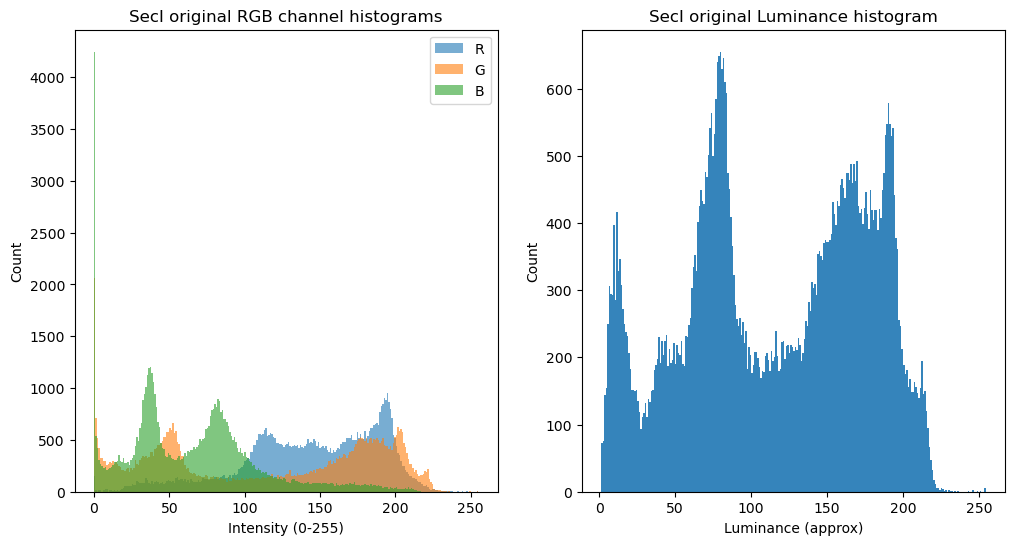

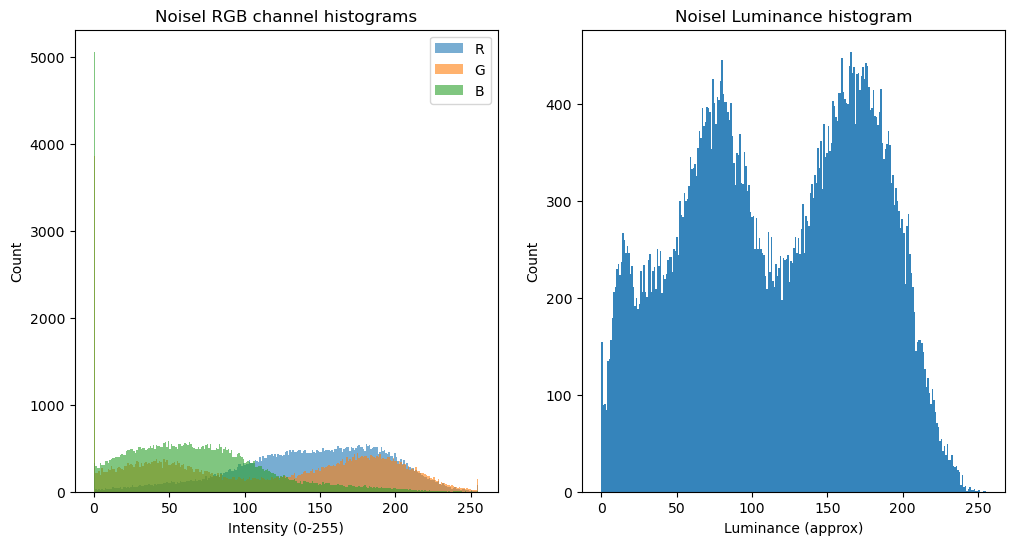

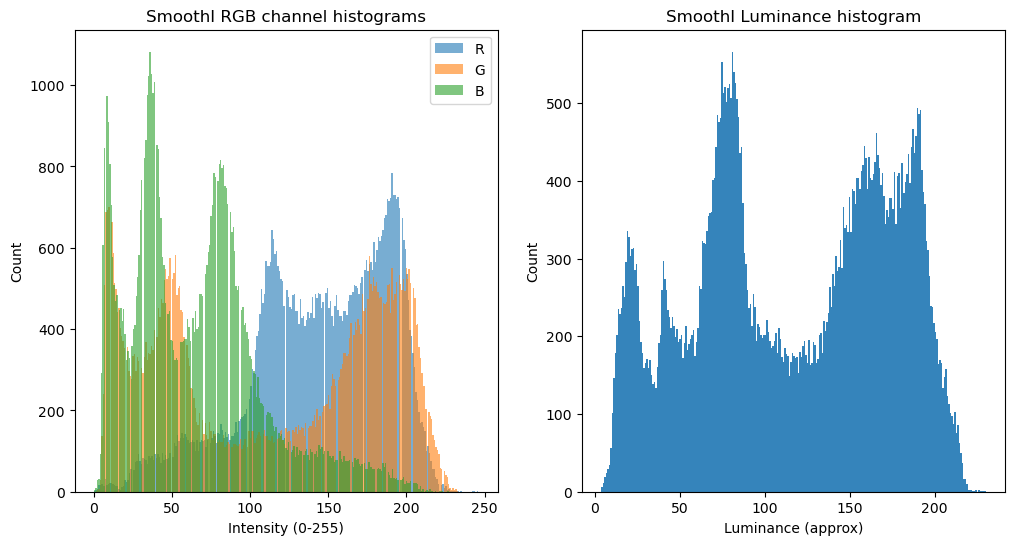

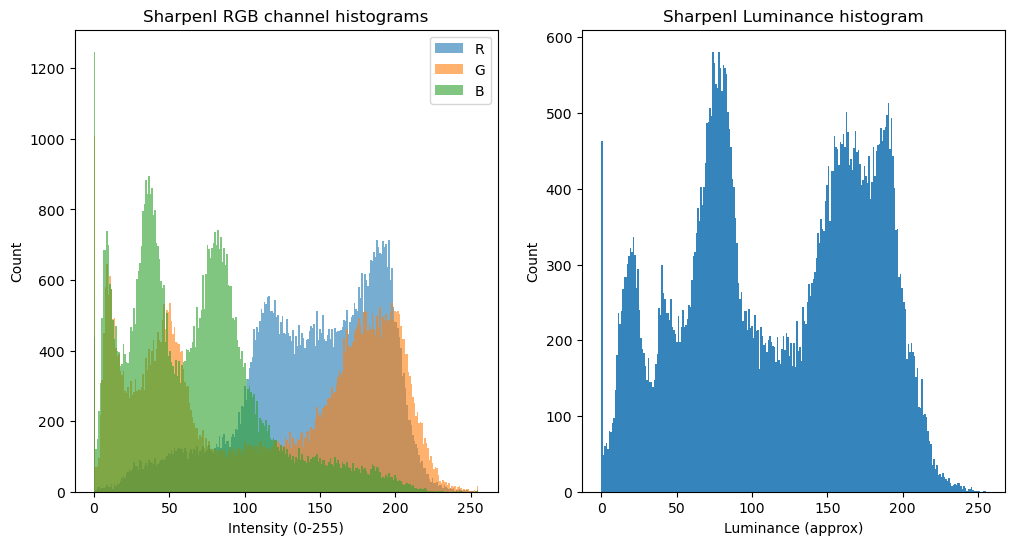

Checklist for SecI processed:
- Added Gaussian noise to SecI -> NoiseI ✔
- Designed smoothing filters (Gaussian, Median, Bilateral) and showed results ✔
- Selected SmoothI (bilateral) and saved it ✔
- Designed sharpening (kernel & unsharp), applied to SmoothI and saved result ✔
- Computed MSE/PSNR comparisons for key steps ✔
Saved: results/SecI_original.png
Saved: results/SecI_noisy.png
Saved: results/SecI_smooth.png
Saved: results/SecI_sharpen.png


In [16]:
# Cell 10 — 4. Complete items: plotting histograms and final checklist for SecI
plot_rgb_histograms(SecI, title_prefix="SecI original")
plot_rgb_histograms(NoiseI, title_prefix="NoiseI")
plot_rgb_histograms(SmoothI, title_prefix="SmoothI")
plot_rgb_histograms(SharpenI, title_prefix="SharpenI")

print("Checklist for SecI processed:")
print("- Added Gaussian noise to SecI -> NoiseI ✔")
print("- Designed smoothing filters (Gaussian, Median, Bilateral) and showed results ✔")
print("- Selected SmoothI (bilateral) and saved it ✔")
print("- Designed sharpening (kernel & unsharp), applied to SmoothI and saved result ✔")
print("- Computed MSE/PSNR comparisons for key steps ✔")

# Save all final outputs if not already
save_image_rgb(os.path.join(out_dir, "SecI_original.png"), SecI)
save_image_rgb(os.path.join(out_dir, "SecI_noisy.png"), NoiseI)
save_image_rgb(os.path.join(out_dir, "SecI_smooth.png"), SmoothI)
save_image_rgb(os.path.join(out_dir, "SecI_sharpen.png"), SharpenI)
